In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_injured = pd.read_csv("accidentes-injury-histo.csv")

/tmp/ipykernel_3829/2128208587.py:1: DtypeWarning: Columns (0: case_id_pkey, 1: juris) have mixed types. Specify dtype option on import or set low_memory=False.
  df_injured = pd.read_csv("accidentes-injury-histo.csv")


In [4]:
df_injured.info()

<class 'pandas.DataFrame'>
RangeIndex: 64694 entries, 0 to 64693
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unique_id                64694 non-null  int64  
 1   cnn_intrsctn_fkey        64657 non-null  float64
 2   cnn_sgmt_fkey            28914 non-null  float64
 3   case_id_pkey             64694 non-null  object 
 4   tb_latitude              64513 non-null  str    
 5   tb_longitude             64513 non-null  str    
 6   geocode_source           64694 non-null  str    
 7   geocode_location         64694 non-null  str    
 8   collision_datetime       64694 non-null  str    
 9   collision_date           64694 non-null  str    
 10  collision_time           64632 non-null  str    
 11  accident_year            64694 non-null  int64  
 12  month                    64694 non-null  str    
 13  day_of_week              64685 non-null  str    
 14  time_cat                 64641 no

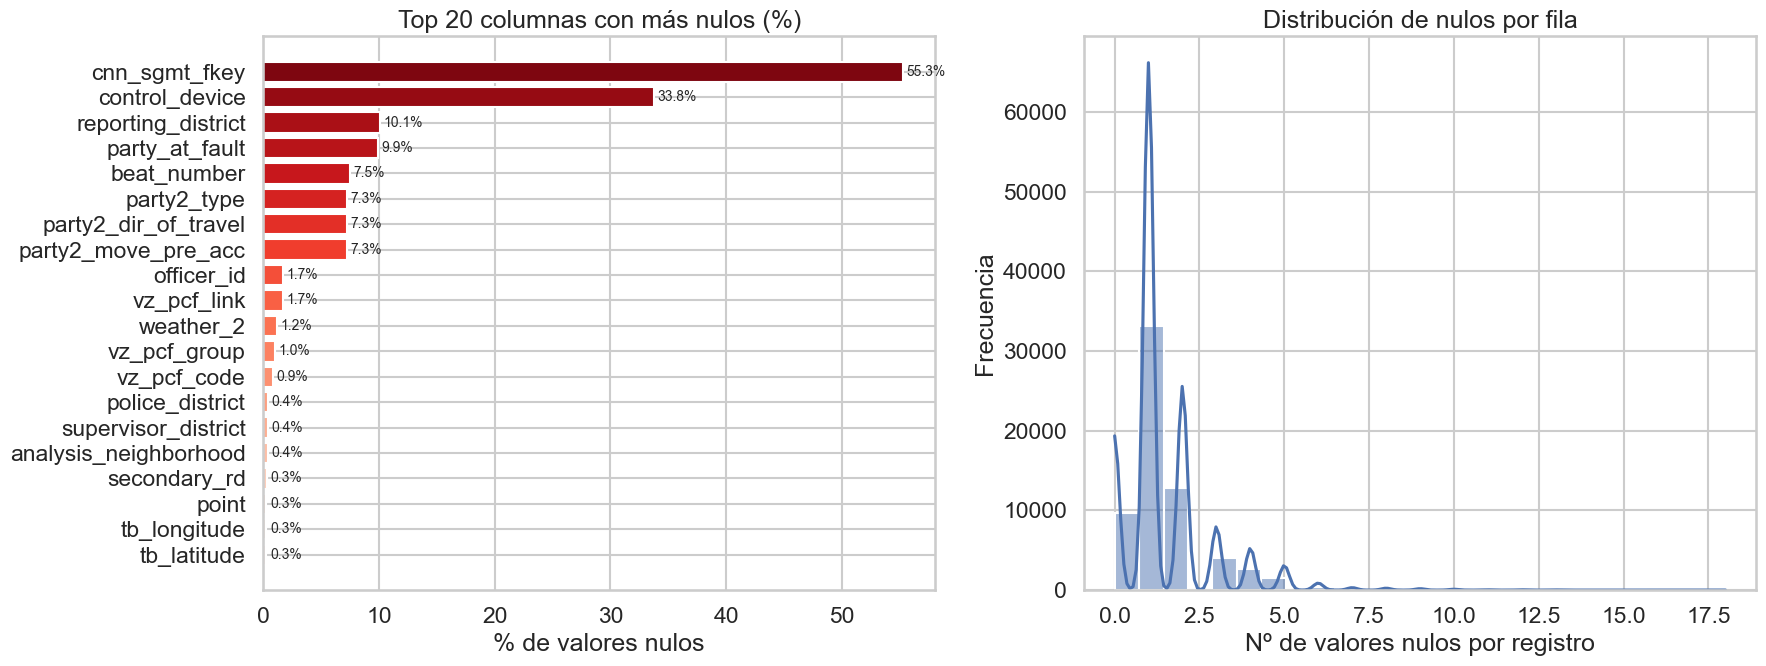

In [6]:
sns.set_theme(style="whitegrid", context="talk")
null_pct = (
    df_injured.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
null_pct = null_pct[null_pct > 0].head(20)

row_nulls = df_injured.isna().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = sns.color_palette("Reds_r", n_colors=len(null_pct))
axes[0].barh(null_pct.index, null_pct.values, color=colors)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 columnas con más nulos (%)")
axes[0].set_xlabel("% de valores nulos")
axes[0].set_ylabel("")

for i, v in enumerate(null_pct.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)

sns.histplot(
    row_nulls,
    bins=25,
    kde=True,
    color="#4C72B0",
    ax=axes[1],
)
axes[1].set_title("Distribución de nulos por fila")
axes[1].set_xlabel("Nº de valores nulos por registro")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### 1. Columnas de localización.
1. Point es identico a tb_latitude y tb_longitude. *Sería la columna a usar en una visualización en mapa.*
2. geocode_source y geocode_location son irrelevantes, la primeraespecifica qué agente es al fuente geográfico, la segunda tiene un único valor.
3. El resto de coumnas son relevantes y nos hablan tanto de en qué calle a ocurrido el accidente, cómo poder dibujar la dirección o el final del accidente si fue mi grabe. Puede ser interesante la columna de "distancia recorrida".

In [4]:
geo_c = ['tb_latitude', 'tb_longitude', 'geocode_source', 'geocode_location', 'juris', 'primary_rd', 'secondary_rd', 'distance', 'direction', 'intersection', 'street_view', 'point']
df_injured.loc[:, geo_c].sample(3)

,tb_latitude,tb_longitude,geocode_source,geocode_location,juris,primary_rd,secondary_rd,distance,direction,intersection,street_view,point
62697,"37,7879502724","-122,433647124",SFPD-INTERIM DB,CITY STREET,3801,FILLMORE ST,PINE ST,0.0,Not Stated,Intersection <= 20ft,https://maps.google.com/maps?q=&layer=c&cbll=3...,POINT (-122.433647124 37.787950272)
16959,"37,77522568093","-122,50802439193",SFPD-CROSSROADS,CITY STREET,3801,BALBOA ST,47TH AVE,0.0,Not Stated,Intersection <= 20ft,https://maps.google.com/maps?q=&layer=c&cbll=3...,POINT (-122.508024392 37.775225681)
57316,"37,7778194501","-122,453446497",SFPD-INTERIM DB,CITY STREET,3801,TURK BLVD,PARKER AVE,18.0,West,Intersection <= 20ft,https://maps.google.com/maps?q=&layer=c&cbll=3...,POINT (-122.453446497 37.77781945)


In [5]:
df_injured.loc[:, geo_c].isnull().sum()

tb_latitude         181
tb_longitude        181
geocode_source        0
geocode_location      0
juris                 1
primary_rd            1
secondary_rd        206
distance             79
direction             1
intersection          1
street_view         126
point               181
dtype: int64

**1.1. geocode_location** *Eliminar*, unicamente hay una categoría.

In [6]:
df_injured.geocode_location.unique()

<StringArray>
['CITY STREET']
Length: 1, dtype: str

Los valores nulos de distancias los imputamos a 0.

In [7]:
df_injured.distance = df_injured.distance.fillna(0)

In [8]:
df_injured.drop(columns=['tb_latitude', 'tb_longitude', 'geocode_location', 'geocode_source', 'street_view', 'secondary_rd'], inplace=True)

In [9]:
df_injured.loc[:,["juris", "intersection", "direction", "primary_rd"]].isnull().sum()

juris           1
intersection    1
direction       1
primary_rd      1
dtype: int64

In [10]:
df_injured = df_injured.dropna(subset=["intersection", "direction", "primary_rd", "point"])

### 2. Columnas de temporales.
1. Esta tabla nos da mucha granularidad a la hora de poder mostrar el momento del accidente. Para el modelo no será útil pero para el BI sí.
2. **Imputamos vlaores nulos de horas y días basandonos en la coluna `collision_datetime`**
3. Eliminamos las que repiten información

In [11]:
time_c = ['collision_datetime', 'collision_date', 'collision_time', 'accident_year', 'month', 'day_of_week', 'time_cat']
df_injured.loc[:, time_c].sample(3)

,collision_datetime,collision_date,collision_time,accident_year,month,day_of_week,time_cat
21493,2010 Sep 30 07:58:00 AM,2010 September 30,07:58:00,2010,September,Thursday,6:01 am to 10:00 am
19016,2014 Aug 05 01:30:00 PM,2014 August 05,13:30:00,2014,August,Tuesday,10:01 am to 2:00 pm
53714,2019 Mar 23 08:56:00 AM,2019 March 23,08:56:00,2019,March,Saturday,6:01 am to 10:00 am


In [12]:
df_injured.loc[:, time_c].info()

<class 'pandas.DataFrame'>
Index: 64512 entries, 0 to 64693
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   collision_datetime  64512 non-null  str  
 1   collision_date      64512 non-null  str  
 2   collision_time      64452 non-null  str  
 3   accident_year       64512 non-null  int64
 4   month               64512 non-null  str  
 5   day_of_week         64503 non-null  str  
 6   time_cat            64461 non-null  str  
dtypes: int64(1), str(6)
memory usage: 3.9 MB


In [13]:
df_injured.loc[:, time_c].isnull().sum()

collision_datetime     0
collision_date         0
collision_time        60
accident_year          0
month                  0
day_of_week            9
time_cat              51
dtype: int64

**2.1. Imputamos los valores nuelos.**

In [14]:
df_injured["collision_datetime"] = pd.to_datetime(df_injured["collision_datetime"])

mask_day = df_injured["day_of_week"].isnull()
df_injured.loc[mask_day, "day_of_week"] = df_injured.loc[mask_day, "collision_datetime"].dt.day_name()

mask_time = df_injured["collision_time"].isnull()
df_injured.loc[mask_time, "collision_time"] = df_injured.loc[mask_time, "collision_datetime"].dt.strftime("%H:%M:%S")

In [15]:
df_injured.drop(columns=['time_cat', 'collision_datetime'], inplace=True)

### 3. Columnas de policía.
1. Información sobre los ajentes que reportan y sus comisarias.
2. **Mantenemos superviso_district para la visualización BI**

In [16]:
police_c = ['officer_id', 'reporting_district', 'beat_number', 'police_district', 'control_device', 'analysis_neighborhood']
df_injured.loc[:, police_c].sample(3)

,officer_id,reporting_district,beat_number,police_district,control_device,analysis_neighborhood
15423,4317,Mission,3D11D,MISSION,Functioning,Mission
24304,1889,PARKC,3F14E,PARK,Functioning,Hayes Valley
30959,2076,SOUTH,3B13D,SOUTHERN,Functioning,Tenderloin


In [17]:
df_injured.drop(columns=police_c, inplace=True)

**Supervisor_district**
1. Conservamos este campo para la inteligencia de negocio.
2. Imputamos los nulos a la moda.
3. Convertimos a String

In [18]:
df_injured.supervisor_district.isnull().sum()

np.int64(81)

In [19]:
# supervisor_district -> str
df_injured['supervisor_district'] = df_injured['supervisor_district'].fillna(df_injured['supervisor_district'].mode()[0])
df_injured['supervisor_district'] = df_injured['supervisor_district'].astype('str')

### 4. Columnas de colisión.
1. Aportan gran cantidad de información sobre el sentido del accidente. Naturaleza de este, causas y partes implicadas.
2. Columnas muy importantes para un modelo de sinisestralidad. Columnas importantísimas cómo: *mviw* y *ped_action*.

In [20]:
colision_c = ['collision_severity', 'type_of_collision', 'mviw', 'ped_action', 'number_killed', 'number_injured']
df_injured.loc[:, colision_c].sample(3)

,collision_severity,type_of_collision,mviw,ped_action,number_killed,number_injured
30733,Injury (Other Visible),Rear End,Other Motor Vehicle,"In Road, Including Shoulder",0.0,1
61156,Injury (Complaint of Pain),Broadside,Other Motor Vehicle,No Pedestrian Involved,0.0,2
6717,Injury (Complaint of Pain),Rear End,Other Motor Vehicle,No Pedestrian Involved,0.0,1


In [21]:
df_injured.collision_severity.value_counts()

collision_severity
Injury (Complaint of Pain)    41020
Injury (Other Visible)        18329
Injury (Severe)                4552
Fatal                           610
Medical                           1
Name: count, dtype: int64

In [22]:
df_injured.type_of_collision.value_counts()

type_of_collision
Broadside             19811
Vehicle/Pedestrian    13365
Rear End              10413
Sideswipe              8525
Head-On                3933
Other                  3370
Hit Object             2452
Not Stated             1495
Overturned             1148
Name: count, dtype: int64

In [23]:
df_injured.mviw.value_counts()

mviw
Other Motor Vehicle               29582
Pedestrian                        15045
Bicycle                            8736
Fixed Object                       2878
Parked Motor Vehicle               2799
Non-Collision                      1527
Not Stated                         1500
Other Object                       1301
Motor Vehicle on Other Roadway      969
Train                               147
Animal                               28
Name: count, dtype: int64

In [24]:
df_injured.ped_action.value_counts()

ped_action
No Pedestrian Involved                       48230
Crossing in Crosswalk at Intersection         9256
Crossing Not in Crosswalk                     3239
In Road, Including Shoulder                   1972
Not in Road                                    864
Not Stated                                     704
Crossing in Crosswalk Not at Intersection      222
Approaching/Leaving School Bus                  14
Not In Road                                     11
Name: count, dtype: int64

In [25]:
df_injured.number_killed = df_injured.number_killed.fillna(0)

### 5. Columnas de carretera.
1. Columans realacionas con el entorno del accidente. **Relación con PCI ??**
1. weather_2 es redundante respecto al 1, no aporta mucho matiz. Al igual que el tiempo, reoad_cond_2 es redundante.

In [26]:
road_c = ['road_surface', 'road_cond_1', 'road_cond_2', 'lighting', 'weather_1', 'weather_2']
df_injured.loc[:, road_c].sample(3)

,road_surface,road_cond_1,road_cond_2,lighting,weather_1,weather_2
61281,Dry,No Unusual Condition,Not Stated,Daylight,Clear,Not Stated
12200,Dry,No Unusual Condition,Not Stated,Dusk - Dawn,Clear,Not Stated
56110,Dry,No Unusual Condition,Not Stated,Daylight,Clear,Not Stated


In [27]:
df_injured.road_cond_1.value_counts()

road_cond_1
No Unusual Condition           60969
Not Stated                      1541
Other                            772
Construction or Repair Zone      518
Holes, Deep Ruts                 267
Obstruction on Roadway           146
Loose Material on Roadway        131
Holes, Deep Rut                   96
Reduced Roadway Width             53
Flooded                           19
Name: count, dtype: int64

In [28]:
df_injured.drop(columns=['weather_2', 'road_cond_2'], inplace=True)

### 6. Columnas de legalidad.
1. Columans relacionadas sobre qué infracción se a cometido y quien tine la culpa en el parte del seguro **(presupongo ??)**
2. Puede aportar información al modelo, sobre todo la infracción y el tipo de vehículo implicado. **Información repetida respecto a las columnas del accidente.**
3. Sobra muchas columnas. Columnas interesantes: *vz_pcf_description*, *party1_move_pre_acc* y quizas *dph_col_grp_description*
4. Todas la columnas vz se son repetitivas, unicamente necesitamos la descripción.

In [29]:
law_c = ['vz_pcf_code', 'vz_pcf_group', 'vz_pcf_description', 'vz_pcf_link', 'dph_col_grp', 'dph_col_grp_description', 'party_at_fault', 'party1_type', 'party1_dir_of_travel', 'party1_move_pre_acc', 'party2_type', 'party2_dir_of_travel', 'party2_move_pre_acc']
df_injured.loc[:, law_c].sample(3)

,vz_pcf_code,vz_pcf_group,vz_pcf_description,vz_pcf_link,dph_col_grp,dph_col_grp_description,party_at_fault,party1_type,party1_dir_of_travel,party1_move_pre_acc,party2_type,party2_dir_of_travel,party2_move_pre_acc
18908,22350,22350,Unsafe speed for prevailing conditions,http://leginfo.legislature.ca.gov/faces/codes_...,AA,Vehicle(s) Only Involved,1.0,Driver,East,Proceeding Straight,Driver,West,Stopped
25052,22350,22350,Unsafe speed for prevailing conditions,http://leginfo.legislature.ca.gov/faces/codes_...,AA,Vehicle(s) Only Involved,1.0,Driver,East,Proceeding Straight,NaN,NaN,NaN
1853,22350,22350,Unsafe speed for prevailing conditions,http://leginfo.legislature.ca.gov/faces/codes_...,AA,Vehicle(s) Only Involved,1.0,Driver,South,Proceeding Straight,Driver,South,Proceeding Straight


In [30]:
df_injured.loc[:, law_c].isnull().sum()

vz_pcf_code                 555
vz_pcf_group                658
vz_pcf_description            0
vz_pcf_link                1070
dph_col_grp                   2
dph_col_grp_description       2
party_at_fault             6362
party1_type                  10
party1_dir_of_travel          9
party1_move_pre_acc           9
party2_type                4666
party2_dir_of_travel       4664
party2_move_pre_acc        4663
dtype: int64

In [31]:
df_injured.party1_type.value_counts()

party1_type
Driver            52672
Bicyclist          5222
Pedestrian         5013
Other              1188
Parked Vehicle      379
Not Stated           27
Bicycle               1
Name: count, dtype: int64

In [32]:
df_injured.party1_move_pre_acc.value_counts()

party1_move_pre_acc
Proceeding Straight                       33456
Making Left Turn                          11266
Making Right Turn                          4074
Changing Lanes                             2203
Other                                      1907
Entering Traffic                           1716
Not Stated                                 1378
Backing                                    1373
Stopped In Road                            1209
Making U Turn                              1199
Parked                                      778
Slowing/Stopping                            694
Passing Other Vehicle                       622
Stopped                                     548
Traveling Wrong Way                         486
Ran Off Road                                419
Parking Maneuver                            359
Other Unsafe Turning                        333
Crossed Into Opposing Lane                  226
Merging                                     182
Crossed Into Opposin

In [33]:
df_injured.dph_col_grp_description.value_counts()

dph_col_grp_description
Vehicle(s) Only Involved                    38167
Vehicle-Pedestrian                          15482
Vehicle-Bicycle                              8636
Bicycle Only                                 1185
Bicycle-Pedestrian                            509
Bicycle-Parked Car                            454
Pedestrian Only or Pedestrian-Parked Car       33
Unknown/Not Stated                             19
Vehicle-Bicycle-Pedestrian                     19
Bicycle-Unknown/Not Stated                      6
Name: count, dtype: int64

In [34]:
null_cols=['party1_type', 'party1_dir_of_travel', 'party1_move_pre_acc', 'party2_type', 'party2_dir_of_travel', 'party2_move_pre_acc', 'dph_col_grp_description']
df_injured.loc[:, null_cols] = df_injured.loc[:, null_cols].fillna("Not Stated")

In [35]:
df_injured.drop(columns=['vz_pcf_code', 'vz_pcf_group', 'vz_pcf_link', 'dph_col_grp', 'party_at_fault'], inplace=True)

**Finalmente quedan unas columnas sobre las actualizaciones del dataset que no importan para nuestro problema.**

In [36]:
metadata_c = ['data_as_of', 'data_updated_at', 'data_loaded_at']
df_injured.loc[:, metadata_c].sample(3)

,data_as_of,data_updated_at,data_loaded_at
17389,2009 Mar 08 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 May 01 12:27:24 PM
15365,2015 Sep 16 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 May 01 12:27:24 PM
49193,2017 Sep 21 12:00:00 AM,2023 Apr 26 12:00:00 AM,2026 May 01 12:27:24 PM


In [37]:
df_injured.drop(columns=metadata_c, inplace=True)

In [38]:
df_injured.isnull().sum()

unique_id                      0
cnn_intrsctn_fkey              0
cnn_sgmt_fkey              35719
case_id_pkey                   0
collision_date                 0
collision_time                 0
accident_year                  0
month                          0
day_of_week                    0
juris                          0
primary_rd                     0
distance                       0
direction                      0
weather_1                      0
collision_severity             0
type_of_collision              0
mviw                           0
ped_action                     0
road_surface                   0
road_cond_1                    0
lighting                       0
intersection                   0
vz_pcf_description             0
number_killed                  0
number_injured                 0
dph_col_grp_description        0
party1_type                    0
party1_dir_of_travel           0
party1_move_pre_acc            0
party2_type                    0
party2_dir

In [39]:
df_injured.to_csv("heridos_limpio.csv",index=False)

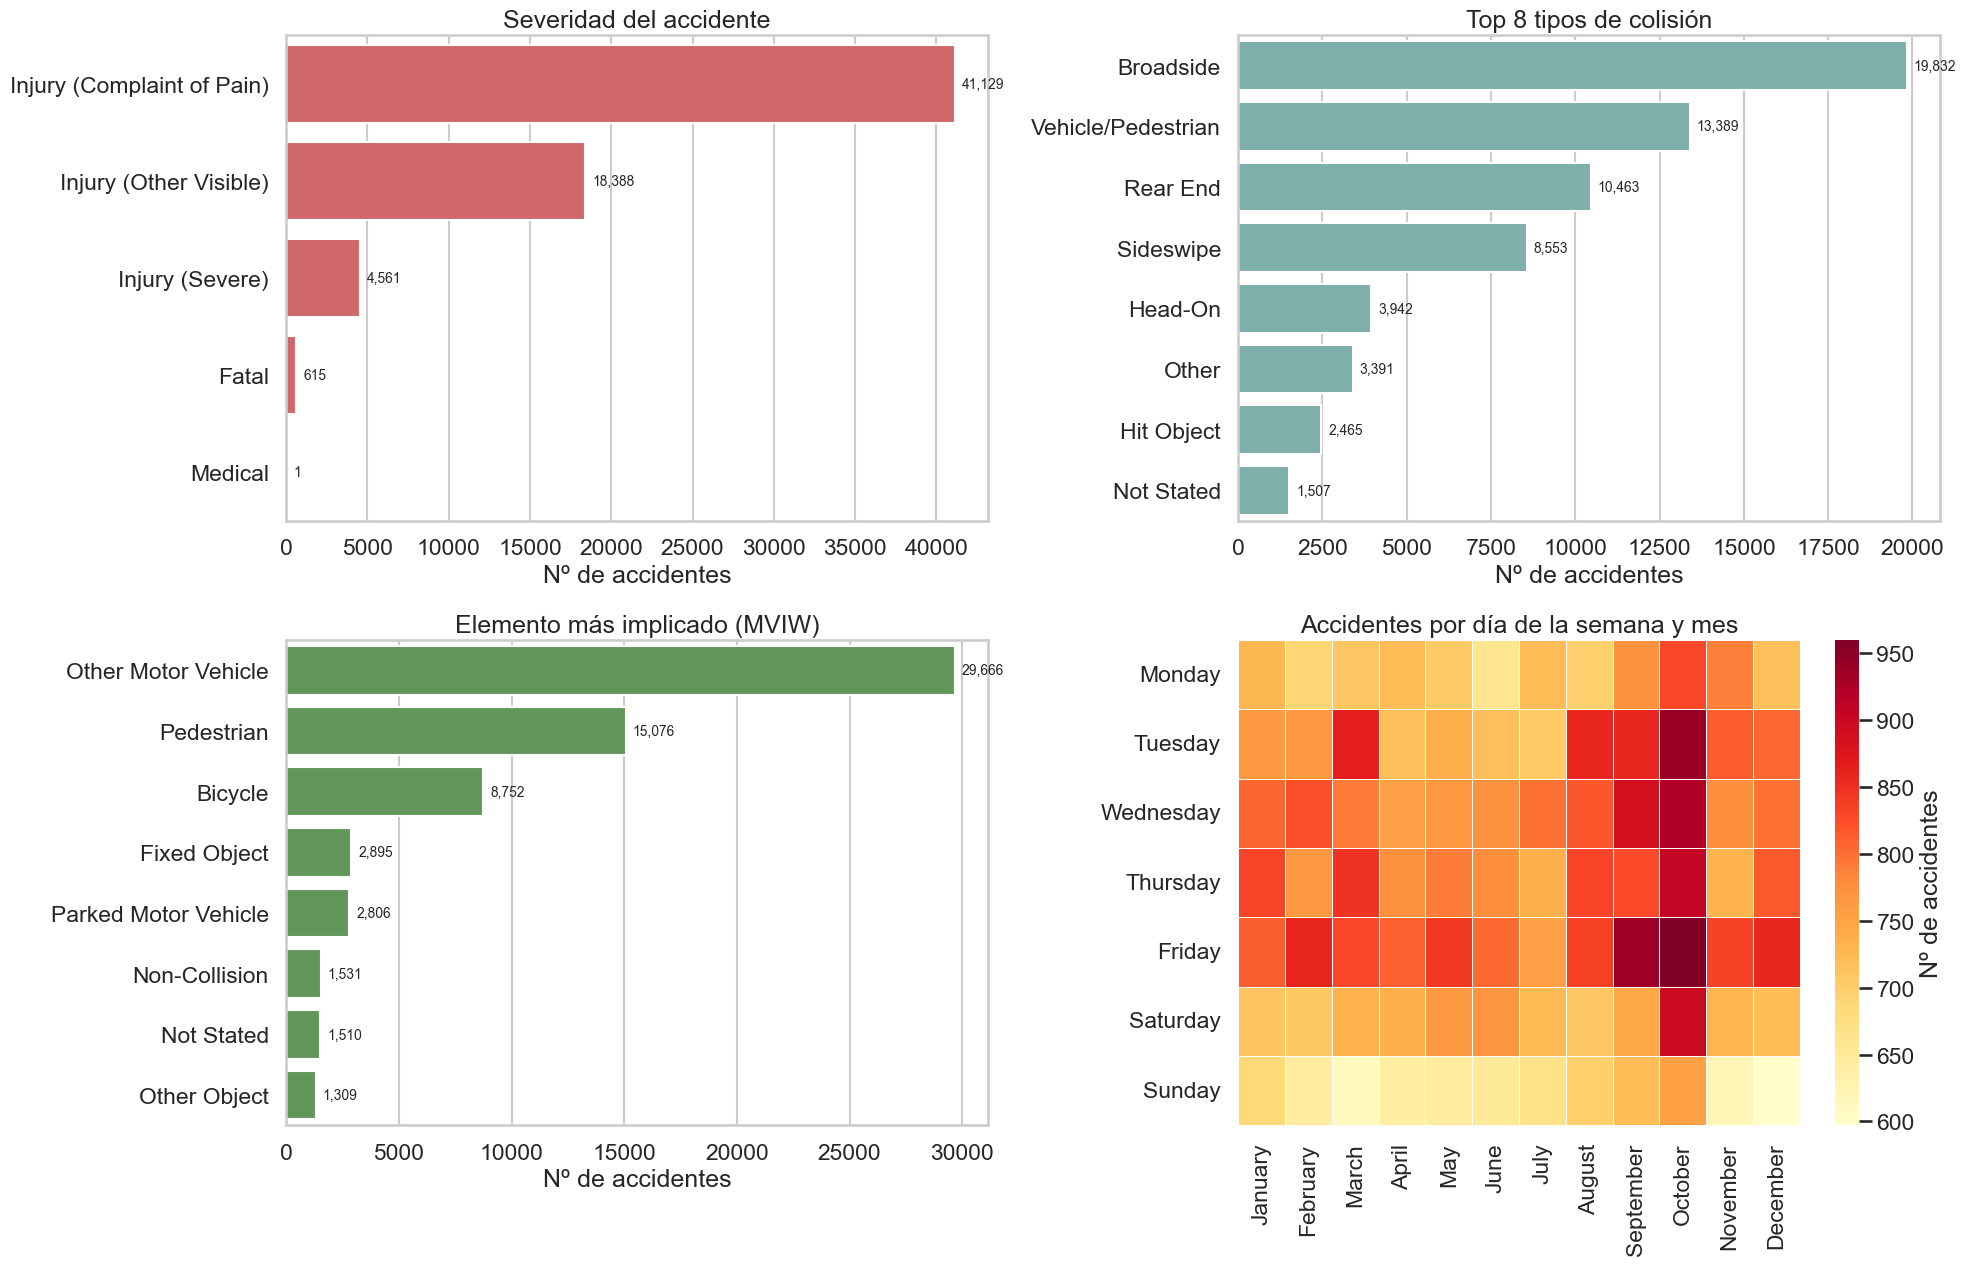

In [7]:
sns.set_theme(style="whitegrid", context="talk")

def add_bar_labels(ax):
    for p in ax.patches:
        w = p.get_width()
        ax.annotate(
            f"{int(w):,}",
            (w, p.get_y() + p.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=10,
        )


month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

heat_data = pd.crosstab(
    pd.Categorical(
        df_injured["day_of_week"],
        categories=day_order,
        ordered=True,
    ),
    pd.Categorical(
        df_injured["month"],
        categories=month_order,
        ordered=True,
    ),
)

fig, axes = plt.subplots(2, 2, figsize=(20, 13))

severity_order = df_injured["collision_severity"].value_counts().index
sns.countplot(
    data=df_injured,
    y="collision_severity",
    order=severity_order,
    color="#E15759",
    ax=axes[0, 0],
)
add_bar_labels(axes[0, 0])
axes[0, 0].set_title("Severidad del accidente")
axes[0, 0].set_xlabel("Nº de accidentes")
axes[0, 0].set_ylabel("")

type_order = (
    df_injured["type_of_collision"]
    .value_counts()
    .head(8)
    .index
)
sns.countplot(
    data=df_injured,
    y="type_of_collision",
    order=type_order,
    color="#76B7B2",
    ax=axes[0, 1],
)
add_bar_labels(axes[0, 1])
axes[0, 1].set_title("Top 8 tipos de colisión")
axes[0, 1].set_xlabel("Nº de accidentes")
axes[0, 1].set_ylabel("")

mviw_order = df_injured["mviw"].value_counts().head(8).index
sns.countplot(
    data=df_injured,
    y="mviw",
    order=mviw_order,
    color="#59A14F",
    ax=axes[1, 0],
)
add_bar_labels(axes[1, 0])
axes[1, 0].set_title("Elemento más implicado (MVIW)")
axes[1, 0].set_xlabel("Nº de accidentes")
axes[1, 0].set_ylabel("")

sns.heatmap(
    heat_data,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Nº de accidentes"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Accidentes por día de la semana y mes")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()